<a href="https://colab.research.google.com/github/villabon89-commits/Proyectos/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [9]:
plans = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Proyecto S7/plans.csv')
users = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Proyecto S7/users_latam.csv')
usage = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Proyecto S7/usage.csv')

In [10]:
plans.head(5) # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [11]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [12]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [13]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [14]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [15]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [16]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [17]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [18]:
print(usage.isna().sum())
print(usage.isna().mean())# cantidad de nulos para usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
---
Rta

**Cantidad de nulos para users**
Se evidencia que las columnas con datos faltantes en el DF users son city con una proporcion del 11.73% y churn_date con el 88.35%

**Cantidad de nulos para usage**
Para el DF usage tenemos las siguientes columnas con su respectiva proporción:
date        0.13%,
duration    55.19%,
length      44.74%

---
- Indica qué harías: ¿imputar, eliminar, ignorar?
---
Rta

Para **users**:
- city          - Imputar
- churn_date    - Ignorar/Eliminar

Para **usage**:
- date          - Imputar
- duration      - Imputar
- lengt         - Imputar


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [19]:
users.describe() # explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`
---
Se observa que la mediana y la media son iguales por tanto es una funcion normal no sesgada
- La columna `age`
---
En la columna age podemos observar que tiene un sesgo, ya que la mediana y media son diferentes, adicionalmente el valor min es -999 lo que nos indica que hay sentinels por imputar

In [20]:
usage.describe()# explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` muestran una relacion en donde id puede indicarse como un movimiento, y user_id como el usuario que genera este movimiento, por lo tanto se evidencia que hay usuarios que generan varios movimientos, y en la distribucion, parece que no estan sesgadas. tambien tiene desviaciones estandar muy grandes lo que nos indica una dispersión alta en los datos.
- Las columnas `length` y `duration` tienen valores atipicos esto dado a la diferencia entre el max y min valor, sin embargo tienen medias y medianas similares, lo que permitirá trabajar con estas medidas sin afectar demasiado la base.

In [21]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` indica que tenemos 7 ciudades en la cual Bogota predomina con 808 acciones y movimientos, sin embargo aun faltan datos.
- La columna `plan` por otro lado solamente tiene 2 planes, en donde predomina el Basico con mas del 50%

In [22]:
# explorar columna categórica de usage
usage['type'].describe()

,type
count,40000
unique,2
top,text
freq,22092



- La columna `type` solo tiene 2 opciones en la que predomina *"text"* con mas del 50%.


---
✍️ **Comentario**: Se observa que son bases relativamente limpias, hay algunas columnas que deben  limpiarse para trabajar en los objetivos solicitados.  

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- ¿Qué acción tomarías?  
---
La columnas que se deben trabajar son las siguientes:

users
- city - Asignar "unknow" a los faltantes.

usage
- date - Modificar "type" y eliminar faltantes.
- duration - Eliminar outlier y modificar sentinels.
- lengt - Eliminar outlier y modificar sentinels.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [23]:
 # Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date']) # completa el código

In [24]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date']) # completa el código

In [25]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.unique())

[2022 2026 2023 2024]


En `reg_date`, hay años mayores a **2024**

In [26]:
# Revisar los años presentes en `date` de usage
print(usage["date"].dt.year.unique())

[2024.   nan]


En `date`, hay valores ausentes.

✍️ **Comentario**: Existen años que para la fecha del archivo aun no se ejecutan(2026), tambien fechas ausenten.

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
---

Hay fechas de '2026' que no han transcurrido y años ausentes o fechas mal escritas que deben eliminarse o cambiar el estado dependiendo el porcentaje de valores que se tengan.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [27]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

,age
count,4000.000000
mean,48.122250
std,17.690408
min,18.000000
25%,33.000000
50%,47.000000
75%,63.000000
max,79.000000


In [28]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?',pd.NA)

# Verificar cambios
users['city'].describe()

,city
count,3435
unique,6
top,Bogotá
freq,808


In [29]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].mask(users['reg_date'].dt.year > 2024, pd.NA)

# Verificar cambios
users['reg_date'].describe()

,reg_date
count,3960
mean,2023-07-03 21:39:41.095273728
min,2022-01-01 00:00:00
25%,2022-10-02 20:17:11.657914368
50%,2023-07-04 10:00:05.401350400
75%,2024-04-03 04:00:05.401350400
max,2024-12-31 00:00:00


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [30]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()

,duration
type,
call,0.000000
text,0.999276


In [31]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

,length
type,
call,0.99933
text,0.00000


En `duration` y `length` se observa que dependen el 99.9% de la columna `type`

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [32]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text', 'is_call', 'duration']].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [33]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration':'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [34]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='inner')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [35]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,reg_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3959,3999.000000,3999.000000,3999.000000
mean,11999.729432,48.124531,2023-07-03 23:11:34.436427776,5.524381,4.478120,23.317054
min,10000.000000,18.000000,2022-01-01 00:00:00,0.000000,0.000000,0.000000
25%,10999.500000,33.000000,2022-10-02 18:38:37.179294720,4.000000,3.000000,11.120000
50%,12000.000000,47.000000,2023-07-04 13:17:14.358589696,5.000000,4.000000,19.780000
75%,12999.500000,63.000000,2024-04-03 05:38:39.879970048,7.000000,6.000000,31.415000
max,13999.000000,79.000000,2024-12-31 00:00:00,17.000000,15.000000,155.690000
std,1154.898108,17.692032,NaN,2.358416,2.144238,18.168095


In [36]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True).round(4) * 100


,proportion
plan,
Basico,64.87
Premium,35.13


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

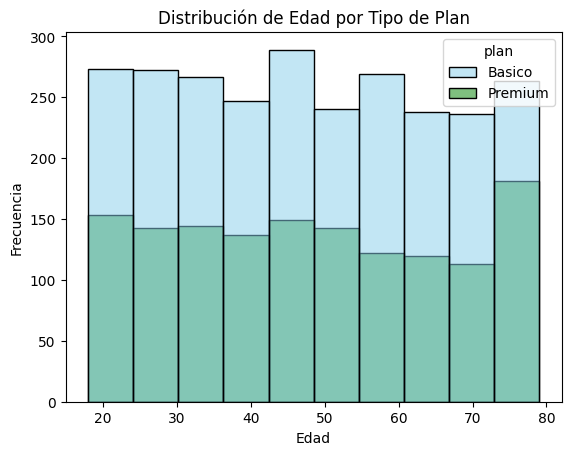

In [37]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', bins=10, hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- La edad está repartida casi en partes iguales a lo que se refiere al tipo de plan.
- Por otro lado observamos que la mayoria de clientes jovenes hasta 50 años les parece mas atractivo tener un plan.
- Hay un descenso visible en la frecuencia Premium entre los 60 y 75 años aproximadamente, antes del repunte final.

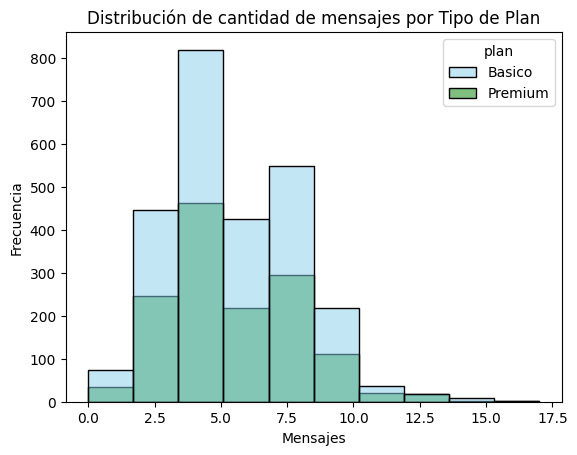

In [38]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', bins=10, hue='plan', palette=['skyblue','green'])
plt.title('Distribución de cantidad de mensajes por Tipo de Plan')
plt.xlabel('Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- La gran mayoría de los usuarios, independientemente de su plan, envían entre 2.5 y 7.5 mensajes. El pico máximo de actividad ocurre en el rango de 5 mensajes, donde el Plan Básico tiene su frecuencia más alta (más de 800 usuarios).
-Distribución similar, volumen distinto: Ambos planes siguen una distribución similar (una campana sesgada a la derecha), lo que indica que el tipo de plan no cambia drásticamente cómo se usa la herramienta, sino cuánta gente la usa.

- Dominio del Básico en volumen: El Plan Básico supera al Premium en casi todos los niveles de frecuencia, especialmente en el uso moderado (2 a 10 mensajes).
- Si el Plan Premium ofrece "mensajes ilimitados" o un límite muy alto como beneficio principal, la gráfica sugiere que este beneficio podría estar subestimado por los usuarios, ya que casi nadie llega a superar los 10 mensajes. El valor real del Premium debería estar en otras funciones, no solo en la cantidad de mensajes.

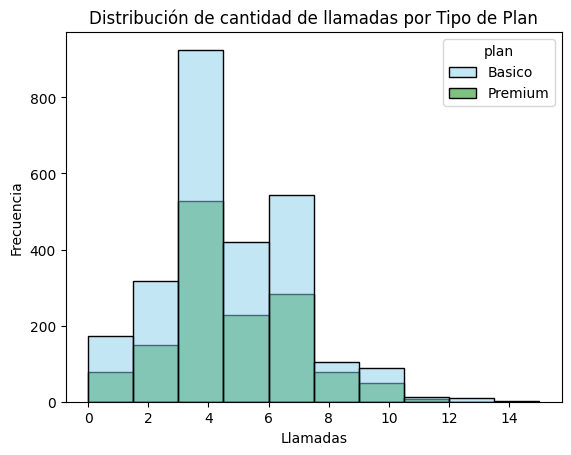

In [39]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', bins=10, hue='plan', palette=['skyblue','green'])
plt.title('Distribución de cantidad de llamadas por Tipo de Plan')
plt.xlabel('Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- Mientras que en los mensajes el pico estaba cerca de 5, en las llamadas la mayor concentración de usuarios (el pico más alto) se encuentra en el rango de 3 a 4 llamadas. Esto indica que la llamada es un recurso más "costoso" o selectivo que el mensaje.
- Existe una "pared" muy clara después de las 7.5 llamadas. Muy pocos usuarios, independientemente de su plan, superan las 8 llamadas.
**Insight**: Si el proceso de servicio postventa requiere más de 8 contactos telefónicos, el asesor está operando fuera del comportamiento estándar del resto del equipo o clientes.
- Hay un volumen considerable de usuarios en el rango de 0 a 2 llamadas. Si este es un proceso de servicio activo, este grupo podría estar infrautilizando la herramienta o resolviendo sus dudas puramente por mensajes.

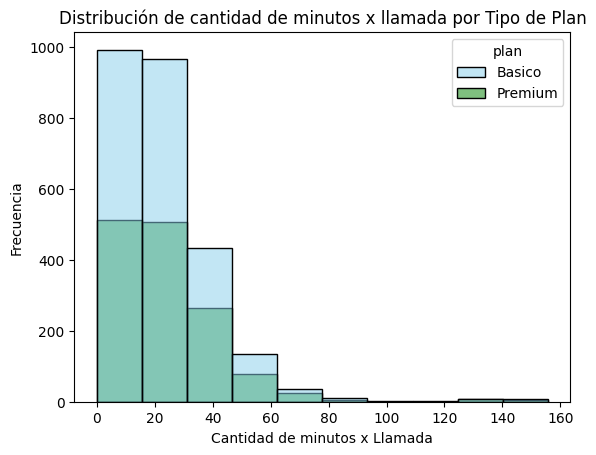

In [40]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=10, hue='plan', palette=['skyblue','green'])
plt.title('Distribución de cantidad de minutos x llamada por Tipo de Plan')
plt.xlabel('Cantidad de minutos x Llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- La gran mayoría de las llamadas se concentran en el rango de 0 a 30 minutos. Hay dos picos masivos: uno entre 0-15 minutos y otro muy similar entre 15-30 minutos.
**Insight**: Esto sugiere que la mayoría de las gestiones se resuelven en menos de media hora, lo cual es positivo para la rotación de atención en Postventa.
- A diferencia de las llamadas totales, aquí la proporción entre el Plan Básico y el Premium se mantiene casi exacta en cada barra.
**Insight**: El tipo de plan no influye en la duración de la llamada. Un cliente Premium no recibe (o no requiere) llamadas más largas que uno Básico. El tiempo de resolución parece depender estrictamente de la complejidad técnica del caso y no del estatus del cliente.
- A partir de los 60 minutos, la frecuencia cae drásticamente, pero existen valores "atípicos" (outliers) que llegan hasta los 160 minutos.
**Riesgo**: Estas llamadas de más de una hora son muy costosas en términos de tiempo del asesor. Sería importante revisar si estos casos son problemas técnicos complejos o ineficiencias en la comunicación que podrían resolverse mejor de forma presencial o por otros canales.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

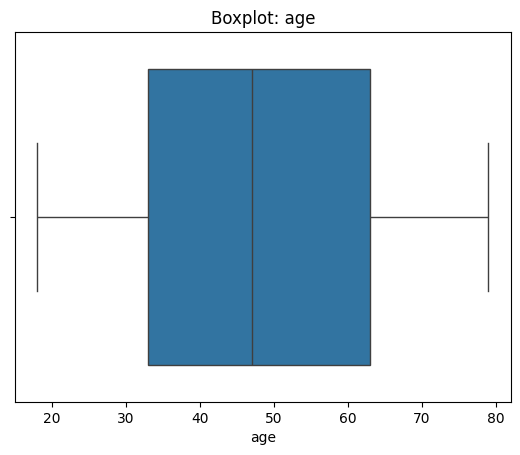

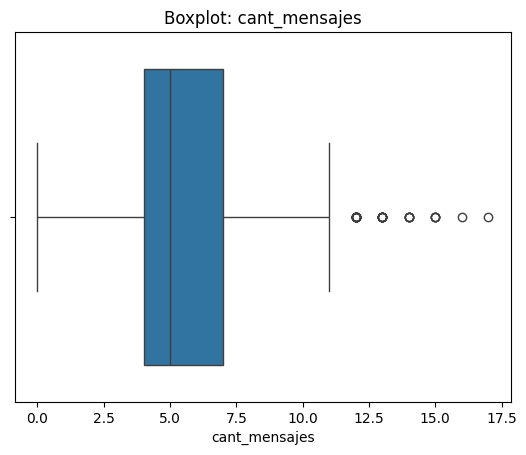

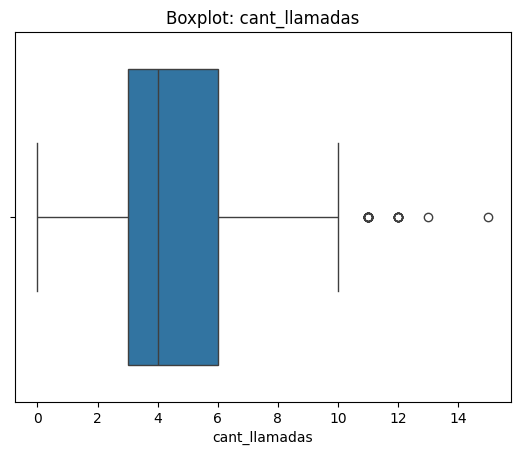

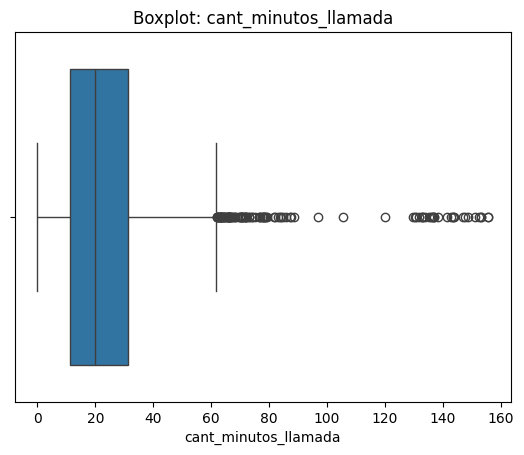

In [41]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
  sns.boxplot(data=user_profile, x=col)
  plt.title(f'Boxplot: {col}')
  plt.show()

💡Insights:

**Age (Edad):**

No presenta outliers. La distribución es bastante equilibrada.

La mediana se sitúa cerca de los 47 años.

El 50% central de la población se encuentra entre los 33 y 63 años aproximadamente (rango intercuartílico), cubriendo un espectro demográfico adulto muy amplio sin casos extremos.

**Cant_mensajes:**

Sí presenta outliers. Se observan valores atípicos a partir de los 12 mensajes.

La mediana es de 5 mensajes.

Aunque la mayoría de los usuarios se concentran entre 4 y 7 mensajes, hay usuarios específicos que "rompen" la norma enviando hasta 17 mensajes, lo que podría indicar casos de servicio con alta complejidad o clientes muy activos.

**Cant_llamadas:**

Sí presenta outliers. Los valores atípicos comienzan después de las 10 llamadas.

La mediana es de 4 llamadas.

La caja es relativamente estrecha (la mayoría hace entre 3 y 6 llamadas), por lo que cualquier usuario que realice 11, 12 o 15 llamadas es considerado un caso excepcional que se sale del estándar de operación.

**Cant_minutos_llamada:**

Sí presenta una gran cantidad de outliers. Es la variable con mayor dispersión extrema. Los valores atípicos inician poco después de los 60 minutos.

La mediana es de 20 minutos.

Se observa una "cola" muy larga de puntos hacia la derecha, con llamadas que llegan hasta los 160 minutos. Esto confirma que, aunque el proceso estándar es ágil (la mayoría termina antes de los 32 minutos), existen incidentes críticos que consumen una cantidad de tiempo desproporcionada.

In [42]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']




In [49]:
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"--- {col} ---")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Límite Inferior (IQR): {lower_bound}")
    print(f"Límite Superior (IQR): {upper_bound}")
    print(f"Valores Mínimo Actual: {user_profile[col].min()}")
    print(f"Valores Máximo Actual: {user_profile[col].max()}\n")

--- cant_mensajes ---
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite Inferior (IQR): -0.5
Límite Superior (IQR): 11.5
Valores Mínimo Actual: 0
Valores Máximo Actual: 17

--- cant_llamadas ---
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite Inferior (IQR): -1.5
Límite Superior (IQR): 10.5
Valores Mínimo Actual: 0
Valores Máximo Actual: 15

--- cant_minutos_llamada ---
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite Inferior (IQR): -19.322500000000005
Límite Superior (IQR): 61.8575
Valores Mínimo Actual: 0.0
Valores Máximo Actual: 155.69



In [43]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener outliers (pocos valores, comportamiento normal)
- cant_llamadas: mantener outliers (pocos valores, comportamiento normal)  
- cant_minutos_llamada: capar outliers (valores posibles pero raros)

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [52]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where( (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 'Bajo uso',
                                      np.where( (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), 'Uso medio', 'Alto uso'))

In [53]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [54]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30, 'Joven',
    np.where(user_profile['age'] < 60, 'Adulto', 'Adulto Mayor')
)

In [55]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

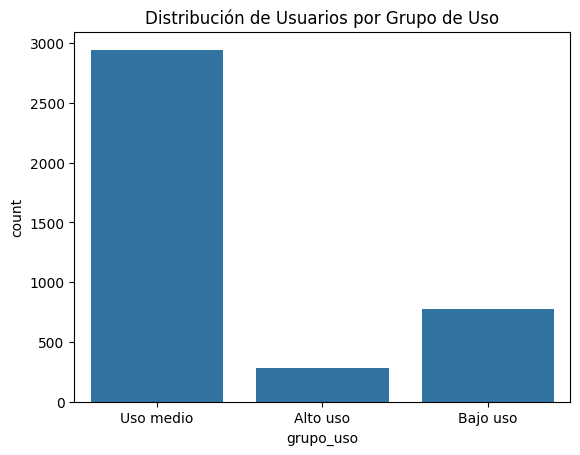

In [56]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de Usuarios por Grupo de Uso')

plt.show()

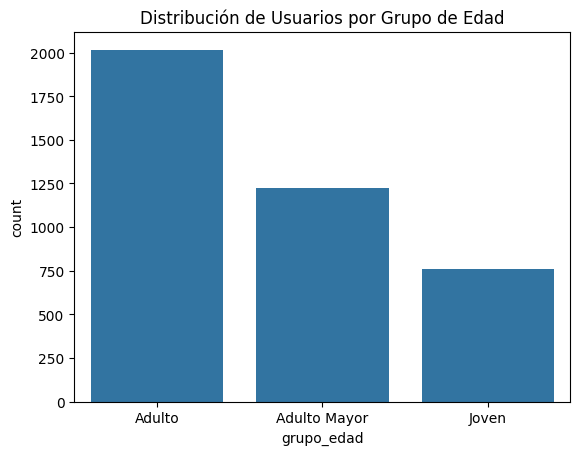

In [57]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de Usuarios por Grupo de Edad')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- **`users` DataFrame**:
    - `city`: 469 valores nulos (11.73%) y sentinels '?' (reemplazados por `pd.NA`).
    - `churn_date`: 3534 valores nulos (88.35%), indicando que la mayoría de los usuarios están activos o la información de churn es incompleta, se decidió ignorar/eliminar por su alta proporción de nulos.
    - `age`: Valores sentinels -999 (reemplazados por la mediana, 47 años).
    - `reg_date`: Fechas futuras (año 2026) (marcadas como `pd.NA`).
- **`usage` DataFrame**:
    - `date`: 50 valores nulos (0.13%).
    - `duration`: 22076 valores nulos (55.19%), que son `MAR` (Missing At Random) ya que su presencia depende directamente del `type` de uso (llamadas vs. mensajes).
    - `length`: 17896 valores nulos (44.74%), también `MAR` y dependientes del `type` de uso.

🔍 **Segmentos por Edad**
- **Joven (edad < 30)**: Representan un segmento importante con necesidades específicas que podrían centrarse en el uso intensivo de datos y mensajes.
- **Adulto (edad < 60)**: El segmento más numeroso y estable, con un uso equilibrado de servicios.
- **Adulto Mayor (edad >= 60)**: Un grupo que podría valorar la simplicidad, tarifas claras y un buen servicio al cliente.

📊 **Segmentos por Nivel de Uso**
- **Bajo uso (llamadas < 5 y mensajes < 5)**: Usuarios que apenas utilizan los servicios, lo que podría indicar insatisfacción, uso de otros operadores, o que el plan no se ajusta a sus necesidades.
- **Uso medio (llamadas < 10 y mensajes < 10)**: La mayoría de los usuarios, con un uso moderado y equilibrado de llamadas y mensajes.
- **Alto uso (resto de casos)**: Usuarios muy activos en llamadas o mensajes (o ambos), probablemente los más leales y dependientes del servicio.

➡️ **Segmentos más valiosos:**
- **Clientes de 'Alto uso'**: Son los más valiosos porque demuestran una alta dependencia y engagement con los servicios de ConnectaTel, lo que se traduce en mayores ingresos y menor churn potencial si se mantienen satisfechos.
- **Clientes 'Adultos' (especialmente los de 'Uso medio' o 'Alto uso')**: Por ser el grupo demográfico más grande y con poder adquisitivo, son clave para el crecimiento sostenido.


- **Patrones de uso extremo (outliers)**:
    - **`cant_mensajes` y `cant_llamadas`**: Se observaron outliers con usuarios enviando hasta 17 mensajes y realizando hasta 15 llamadas. Esto implica que, aunque la mayoría tiene un uso moderado, existe un pequeño grupo de clientes muy activos que podrían estar experimentando problemas complejos o usando el servicio intensivamente para su negocio o vida personal. Estos outliers no deben eliminarse, sino estudiarse, ya que representan un comportamiento real, aunque extremo.
    - **`cant_minutos_llamada`**: Se encontraron muchas llamadas de duración extremadamente larga, llegando hasta 155 minutos. Esto es significativo porque las llamadas de más de 60 minutos son costosas en tiempo de atención al cliente y podrían indicar problemas técnicos complejos, ineficiencias en el soporte, o clientes con necesidades muy particulares. Estos outliers (por encima de 61.85 minutos según IQR) sugieren un área crítica de mejora en la gestión de llamadas.

💡 **Recomendaciones**
- **Optimización de planes:**
    - **Para clientes de 'Bajo uso'**: Investigar las razones de su bajo consumo. Ofrecer micro-planes o promociones personalizadas para aumentar su engagement o evitar el churn. Podría haber un nicho para un plan de 'emergencia' o 'solo datos' de bajo costo.
    - **Para clientes 'Premium'**: Reevaluar los beneficios. Si los usuarios Premium no utilizan al máximo los mensajes o minutos incluidos, se podría recalibrar el plan para ofrecer beneficios más atractivos (ej. más GB, servicios de valor añadido, descuentos en dispositivos) que justifiquen el costo.
    - **Para clientes de 'Alto uso'**: Crear planes de fidelización o 'Club Premium' que ofrezcan ventajas exclusivas (soporte prioritario, gigas ilimitados, etc.) para retener a estos usuarios de alto valor.
- **Gestión de outliers en `cant_minutos_llamada`:**
    - Analizar las causas de las llamadas extremadamente largas. Podrían ser indicadores de problemas recurrentes, falta de capacitación de agentes, o procesos ineficientes. Implementar un protocolo para escalar estas llamadas o revisarlas post-servicio para identificar oportunidades de mejora.
    - Ofrecer canales alternativos (chatbots, tutoriales en línea) para resolver problemas comunes que actualmente derivan en llamadas largas, reduciendo así la carga operativa.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

https://github.com/villabon89-commits/Proyectos.git

Link a repositorio público del proyecto: `LINK a tu repo aquí`